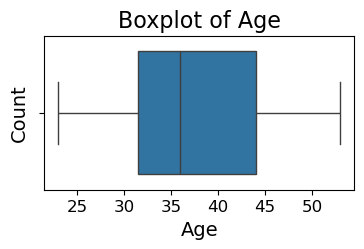

Empty DataFrame
Columns: [Age, Gender, Education Level, Job Title, Years of Experience, Salary]
Index: []


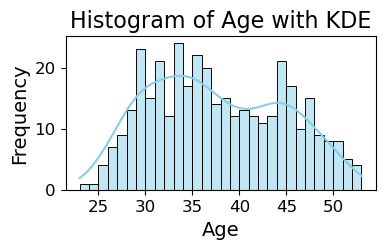

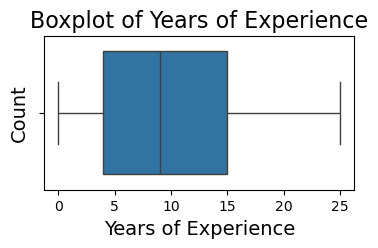

Empty DataFrame
Columns: [Age, Gender, Education Level, Job Title, Years of Experience, Salary]
Index: []


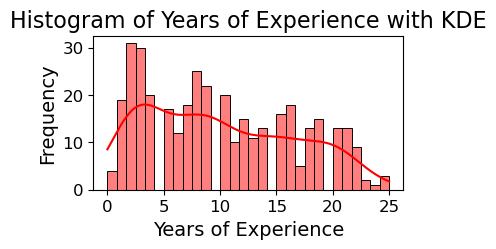

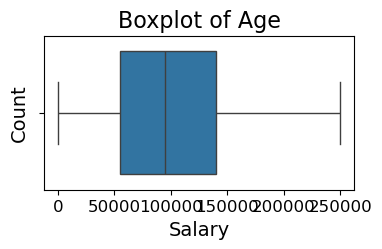

Empty DataFrame
Columns: [Age, Gender, Education Level, Job Title, Years of Experience, Salary]
Index: []


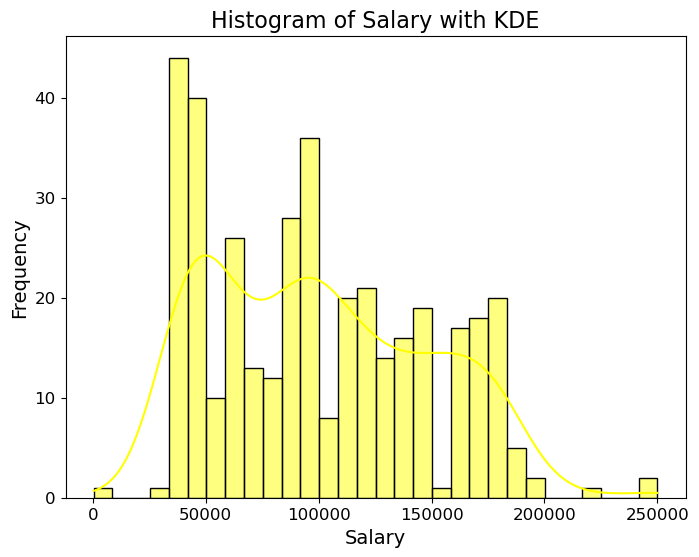

C:\Users\HP\AppData\Local\Temp\ipykernel_21272\1568693133.py:144: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_salary = df.groupby('Age_Group')['Salary'].mean()


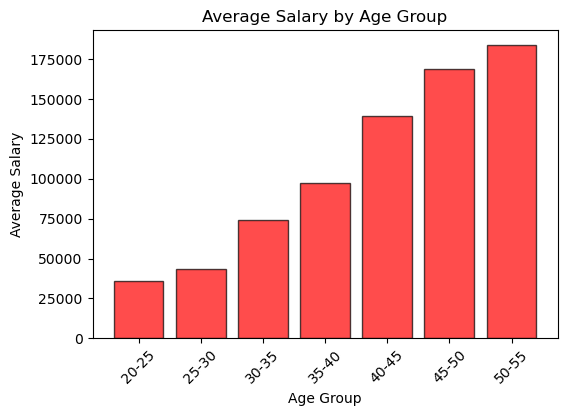

C:\Users\HP\AppData\Local\Temp\ipykernel_21272\1568693133.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education Level', y='Salary', data=df, palette='coolwarm')


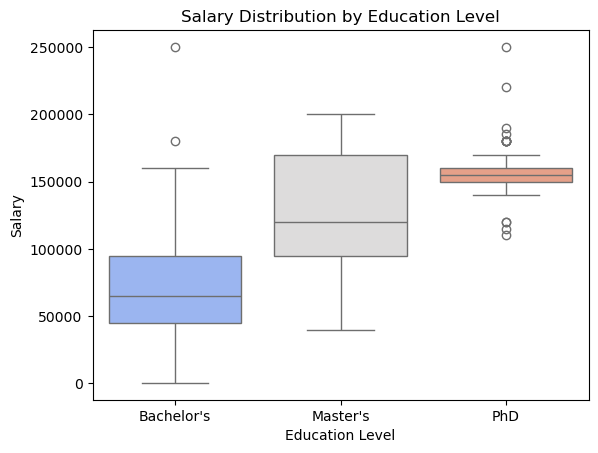

C:\Users\HP\AppData\Local\Temp\ipykernel_21272\1568693133.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Gender', y='Salary', data=df, palette='Set3')


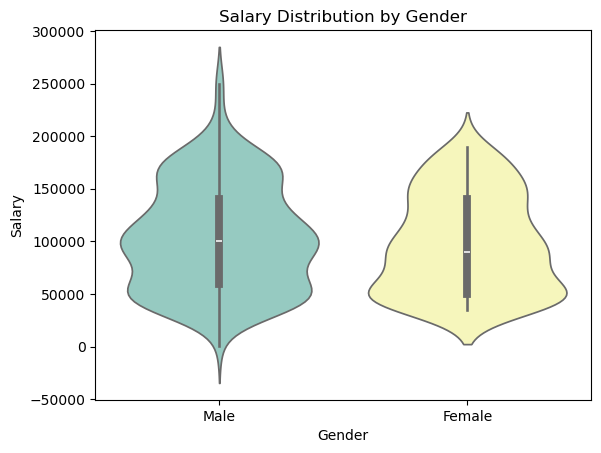

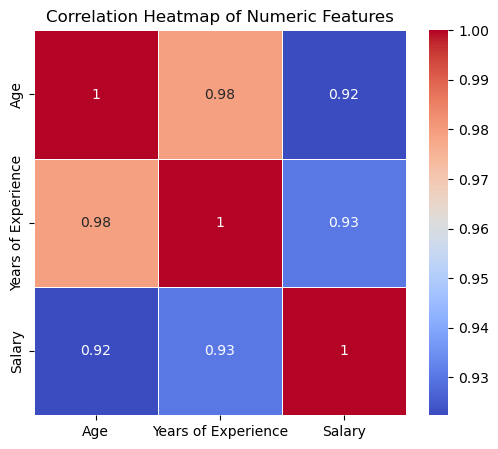

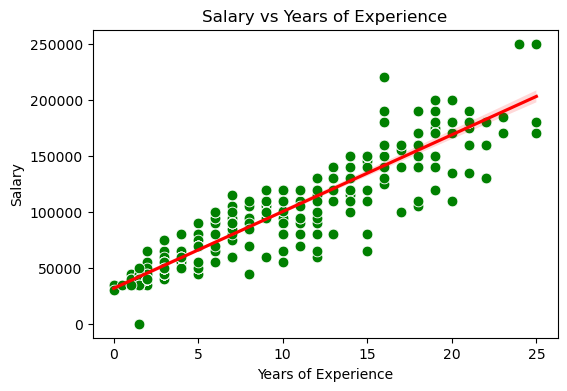

                Age  Years of Experience  Experience_Level
count  3.750000e+02         3.750000e+02      3.750000e+02
mean  -3.221127e-16         1.421085e-17     -2.321106e-16
std    1.001336e+00         1.001336e+00      1.001336e+00
min   -2.049733e+00        -1.535944e+00     -1.926262e+00
25%   -8.424733e-01        -9.234549e-01     -9.433628e-01
50%   -2.033359e-01        -1.578433e-01     -1.359302e-02
75%    9.329083e-01         7.608907e-01      8.695407e-01
max    2.211183e+00         2.292114e+00      2.005336e+00
Predicted Salary: 174214.0306912604
Mean Absolute Error (MAE): 10485.912418187716
Mean Squared Error (MSE): 250535106.85735416
Root Mean Squared Error (RMSE): 15828.300820282453
R² Score: 0.896579822545761
       Actual      Predicted         Error
167  150000.0  174214.030691 -24214.030691
33    65000.0   93680.285094 -28680.285094
15   125000.0  131177.414778  -6177.414778
316   80000.0   85611.392674  -5611.392674
57   140000.0  160093.787334 -20093.787334
291  

Enter Age:  22
Enter Years of Experience:  5


Gender options: Male / Female


Enter Gender:  Female


Education options: Bachelor's / Master's / PhD


Enter Education Level:  Bachelor's



💰 Predicted Salary: Rs. 30214.24


In [4]:
#Salary prediction thorugh Linear Regression
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

"""-----------------------------------------
        DATA COLLECTION
-----------------------------------------"""
df=pd.read_csv("Salary Data.csv")
df.head()
"""-----------------------------------------
        DATA CLEANIING
-----------------------------------------"""
#Filling missing values in all columns
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Education Level'] = df['Education Level'].fillna(df['Education Level'].mode()[0])
df['Job Title'] = df['Job Title'].fillna(df['Job Title'].mode()[0])
df['Years of Experience']=df['Years of Experience'].fillna(df['Years of Experience'].mean())
df['Salary']=df['Salary'].fillna(df['Salary'].mean())
df.isnull().sum()
df.describe()
"""-----------------------------------------
     HANDLING/CHECKING OUTLIERS
-----------------------------------------"""
#Checkinh outliers exists or not
#(1)Visual checking
# Set figure size
plt.figure(figsize=(4,2))  # width=10, height=6
# Create boxplot with custom labels
sns.boxplot(x=df['Age'])
# Customize labels and title
plt.xlabel('Age', fontsize=14)       # X-axis label
plt.ylabel('Count', fontsize=14)     # Y-axis label
plt.title('Boxplot of Age', fontsize=16)  # Title
# Customize tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()
#Also checking statistically
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]
print(outliers)
#check thourgh histogram
plt.figure(figsize=(4,2))
# Histogram with KDE overlay
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue', edgecolor='black')
# Labels and title
plt.xlabel('Age', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Histogram of Age with KDE', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()
#---------Years of experience---------
plt.figure(figsize=(4,2))
sns.boxplot(x=df['Years of Experience'])
plt.xlabel('Years of Experience', fontsize=14)       # X-axis label
plt.ylabel('Count', fontsize=14)     # Y-axis label
plt.title('Boxplot of Years of Experience', fontsize=16)  # Title
plt.show()
#Check statistcally
Q1=df['Years of Experience'].quantile(0.25)
Q3=df['Years of Experience'].quantile(0.75)
IQR=Q3-Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[(df['Years of Experience'] < lower) | (df['Years of Experience'] > upper)]
print(outliers)
plt.figure(figsize=(4,2))
# Histogram with KDE overlay
sns.histplot(df['Years of Experience'], bins=30, kde=True, color='red', edgecolor='black')
# Labels and title
plt.xlabel('Years of Experience', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Histogram of Years of Experience with KDE', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()
#-------------Salary-------------
# Set figure size
plt.figure(figsize=(4,2))  # width=10, height=6
# Create boxplot with custom labels
sns.boxplot(x=df['Salary'])
# Customize labels and title
plt.xlabel('Salary', fontsize=14)       # X-axis label
plt.ylabel('Count', fontsize=14)     # Y-axis label
plt.title('Boxplot of Age', fontsize=16)  # Title
# Customize tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()
#Also checking statistically
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[(df['Salary'] < lower) | (df['Salary'] > upper)]
print(outliers)
#check thourgh histogram
plt.figure(figsize=(8,6))
# Histogram with KDE overlay
sns.histplot(df['Salary'], bins=30, kde=True, color='yellow', edgecolor='black')
# Labels and title
plt.xlabel('Salary', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Histogram of Salary with KDE', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()
#-----Now we move towards visualization-------------

"""-----------------------------------------
     EDA(EXPLORATORY DATA ANALYSIS)
----------------------------------------"""

#we'll plot each visualization to understand graphs
"""(~)Answer the following quetsion thourgh visualization:
1)which age group has max salary and which has lowest?[Bar chart]
2)which qualification has more salary?[Bar chart]
3)Which gender has more salary ?[Bar chart]
5)Which numeric features are strongly correlated with Salary?"""
#Bar Chart(Age vs salary)
plt.figure(figsize=(6,4))
"""To check range of age for histogram
minval=df['Age'].min()
maxval=df['Age'].max()
print(minval)
print(maxval)"""
bins=[20,25,30,35,40,45,50,55]
labels = ['20-25','25-30','30-35','35-40','40-45','45-50','50-55']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_salary = df.groupby('Age_Group')['Salary'].mean()
plt.bar(age_salary.index, age_salary.values, color='red', edgecolor='black', alpha=0.7)
plt.xlabel('Age Group')
plt.ylabel('Average Salary')
plt.title('Average Salary by Age Group')
plt.xticks(rotation=45)
plt.show()
#Salary increses accoridng to age(Older people have more salary as compared to younger ones)
#Education vs salary
sns.boxplot(x='Education Level', y='Salary', data=df, palette='coolwarm')
plt.xlabel('Education Level')
plt.ylabel('Salary')
plt.title('Salary Distribution by Education Level')
plt.show()
#Gender vs salary
sns.violinplot(x='Gender', y='Salary', data=df, palette='Set3')
plt.xlabel('Gender')
plt.ylabel('Salary')
plt.title('Salary Distribution by Gender')
plt.show()
#Heatmap(Checking correlation between numeric variables)
numeric_cols = ['Age', 'Years of Experience', 'Salary']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()
#Scatter plot to check how Salary increases with Years of Experience
plt.figure(figsize=(6,4))
sns.scatterplot(x='Years of Experience', y='Salary', data=df, color='green', s=60)
sns.regplot(x='Years of Experience', y='Salary', data=df, scatter=False, color='red')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience')
plt.show()

"""-----------------------------------------
        FEATURE ENGINEEREING
-----------------------------------------"""
#---------Feature Creation-----------
df['Experience_Level'] = df['Years of Experience'] / df['Age']
df['Age_Group'] = pd.cut(df['Age'],bins=[20,25,30,35,40,45,50,55],labels=['20-25','25-30','30-35','35-40','40-45','45-50','50-55'])

#---------Feature Transformation----------
# 2️⃣ Gender → One-Hot Encoding
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)
# 3️⃣ Education Level → Ordinal Encoding
education_mapping = {
    "Bachelor's": 1,
    "Master's": 2,
    "PhD": 3
}
df['Education_Level'] = df['Education Level'].map(education_mapping)
# Drop original string column
df.drop(columns=['Education Level'], inplace=True)
# 4️⃣ Age_Group → One-Hot Encoding
df = pd.get_dummies(df, columns=['Age_Group'], drop_first=True)

#------------Feature Scaling-----------
scaler = StandardScaler()
scale_cols = ['Age', 'Years of Experience', 'Experience_Level']
df[scale_cols] = scaler.fit_transform(df[scale_cols])
print(df[scale_cols].describe())
df.head()
#derooping irrelevant column
df.drop(columns=['Job Title'], inplace=True)

"""-----------------------------------------
        Train Test Split
-----------------------------------------"""

X=df.drop('Salary',axis=1)
y=df['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
# Predict salaries for test data
# Make predictions on test data
y_pred = model.predict(X_test)

# Pick one sample from test data
sample = X_test.iloc[[0]]

# Predict salary
predicted_salary = model.predict(sample)

print("Predicted Salary:", predicted_salary[0])
"""-----------------------------------------
        Model Evaluation
-----------------------------------------"""
# 1️⃣ MAE – Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

# 2️⃣ MSE – Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

# 3️⃣ RMSE – Root Mean Squared Error
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

# 4️⃣ R² Score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

#checking correctness of predictions
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Error': y_test - y_pred
})
print(results.head(10))
"""-----------------------------------------
        Saving my model
-----------------------------------------"""
import joblib
joblib.dump(model, 'Salarypred_linearRegression.pkl')
joblib.dump(scaler, 'scaler.pkl')
feature_columns = X.columns
joblib.dump(feature_columns, 'features.pkl')

# -----------------------------------------
#      User Input Salary Prediction
# -----------------------------------------

# Load saved objects
model = joblib.load('Salarypred_linearRegression.pkl')
scaler = joblib.load('scaler.pkl')
features = joblib.load('features.pkl')

print("\n--- Predict Salary from User Input ---")

# 🔹 Take numeric inputs
age = float(input("Enter Age: "))
experience = float(input("Enter Years of Experience: "))

# 🔹 Gender
print("Gender options: Male / Female")
gender = input("Enter Gender: ").strip()

# 🔹 Education
print("Education options: Bachelor's / Master's / PhD")
education = input("Enter Education Level: ").strip()

# 🔹 Create empty feature dict
user_input = dict.fromkeys(features, 0)

# 🔹 Add numeric features
user_input['Age'] = age
user_input['Years of Experience'] = experience
user_input['Experience_Level'] = experience / age

# 🔹 Gender encoding
if gender.lower() == 'male':
    user_input['Gender_Male'] = 1

# 🔹 Education encoding
education_mapping = {
    "Bachelor's": 1,
    "Master's": 2,
    "PhD": 3
}
user_input['Education_Level'] = education_mapping.get(education, 1)

# 🔹 Age group encoding
if 20 <= age < 25:
    user_input['Age_Group_25-30'] = 1
elif 25 <= age < 30:
    user_input['Age_Group_30-35'] = 1
elif 30 <= age < 35:
    user_input['Age_Group_35-40'] = 1
elif 35 <= age < 40:
    user_input['Age_Group_40-45'] = 1
elif 40 <= age < 45:
    user_input['Age_Group_45-50'] = 1
elif 45 <= age <= 55:
    user_input['Age_Group_50-55'] = 1

# 🔹 Convert to DataFrame
input_df = pd.DataFrame([user_input])

# 🔹 Scale numeric columns (IMPORTANT)
scale_cols = ['Age', 'Years of Experience', 'Experience_Level']
input_df[scale_cols] = scaler.transform(input_df[scale_cols])

# 🔹 Predict salary
predicted_salary = model.predict(input_df)[0]

print("\n💰 Predicted Salary: Rs.", round(predicted_salary, 2))
